In [40]:
import mlflow
import numpy as np
import pylab as plt
import pandas as pd

In [29]:
!rsync -avz cluster.ies:/mnt/work/dhuseljic/mlflow/perf_dal /home/dhuseljic/mlflow

receiving incremental file list
perf_dal/optimal/213602819063889389/
perf_dal/optimal/213602819063889389/2ec0850c478c4b9cb0c3a85e73efb4f5/
perf_dal/optimal/213602819063889389/2ec0850c478c4b9cb0c3a85e73efb4f5/meta.yaml
perf_dal/optimal/213602819063889389/2ec0850c478c4b9cb0c3a85e73efb4f5/artifacts/
perf_dal/optimal/213602819063889389/2ec0850c478c4b9cb0c3a85e73efb4f5/metrics/
perf_dal/optimal/213602819063889389/2ec0850c478c4b9cb0c3a85e73efb4f5/metrics/ACE
perf_dal/optimal/213602819063889389/2ec0850c478c4b9cb0c3a85e73efb4f5/metrics/BS
perf_dal/optimal/213602819063889389/2ec0850c478c4b9cb0c3a85e73efb4f5/metrics/ECE
perf_dal/optimal/213602819063889389/2ec0850c478c4b9cb0c3a85e73efb4f5/metrics/NLL
perf_dal/optimal/213602819063889389/2ec0850c478c4b9cb0c3a85e73efb4f5/metrics/accuracy
perf_dal/optimal/213602819063889389/2ec0850c478c4b9cb0c3a85e73efb4f5/metrics/query_time
perf_dal/optimal/213602819063889389/2ec0850c478c4b9cb0c3a85e73efb4f5/metrics/reliability
perf_dal/optimal/213602819063889389/2e

## Strategies

In [41]:
from collections import defaultdict

client = mlflow.tracking.MlflowClient(tracking_uri=f'file:////home/dhuseljic/mlflow/perf_dal/optimal/')
experiment_id = client.get_experiment_by_name('optimal_v1').experiment_id
query_list = [
    "parameter.dataset_name= 'cifar10'",
]
runs_strategies = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
print('Found {} experiments'.format(len(runs_strategies)))

run_per_strat = defaultdict(list)
acc_curves_strategies = defaultdict(list)
for run in runs_strategies:
    key = run.data.params['al.strategy']
    run_per_strat[key].append(run)
    acc_curves_strategies[key].append([m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')])

for key, val in acc_curves_strategies.items():
    print('{:20} {:5}'.format(key, len(val)))

Found 80 experiments
typiclust               20
margin                  20
random                  20
optimal                 20


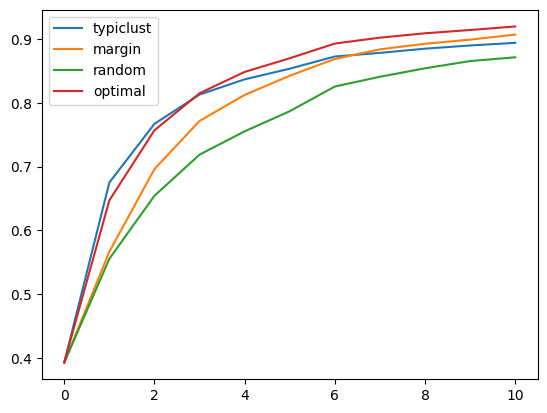

In [42]:
for key in acc_curves_strategies:
    plt.plot(np.mean(acc_curves_strategies[key], axis=0), label=key)
    # plt.plot(np.mean(acc_curves[key], axis=0) - np.mean(acc_curves_strategies['random'], axis=0), label=key)
    # plt.plot(np.mean(acc_curves[key], axis=0) - np.mean(acc_curves['optimal'], axis=0), label=key)
plt.legend()

## Ablations

In [44]:
# client = mlflow.tracking.MlflowClient(tracking_uri=f'sqlite:///decision_flips.db')
# experiment_id = client.get_experiment_by_name('decision_flips').experiment_id
# client = mlflow.tracking.MlflowClient(tracking_uri=f'file:////home/dhuseljic/mlflow/perf_dal/optimal/')
experiment_id = client.get_experiment_by_name('num_batches_v1').experiment_id
# experiment_id = client.get_experiment_by_name('retraining_v1').experiment_id
# experiment_id = client.get_experiment_by_name('gamma_v1').experiment_id
# experiment_id = client.get_experiment_by_name('mc_samples').experiment_id
# experiment_id = client.get_experiment_by_name('perf_estimation_v1').experiment_id
query_list = [
    "parameter.dataset_name= 'cifar10'",
    # "parameter.al.gamma = '1'",
]
runs = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
print('Found {} experiments'.format(len(runs)))

Found 220 experiments


In [54]:
from collections import defaultdict

acc_curves = defaultdict(list)
# num_batches_unique = np.unique([int(run.data.params['al.num_batches']) for run in runs])

for run in runs:
    # key = run.data.params['al.strategy']
    # key = int(run.data.params['al.num_mc_labels'])
    key = int(run.data.params['al.optimal.num_batches'])
    # key = int(run.data.params['al.optimal.num_retraining_epochs'])
    # key = run.data.params['al.optimal.gamma']
    # key = run.data.params['al.optimal.loss']
    # if run.data.params['al.strategy'] == 'random': continue # remove random
    # if run.data.params['al.optimal.use_val_ds'] == 'False': 
    #     key = 'labeled_' + key
    acc_curves[key].append([m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')])

for key, val in acc_curves.items():
    print('{:30} {:5}'.format(key, len(val)))

                         10000    20
                          5000    20
                          2000    20
                          1000    20
                           500    20
                           200    20
                           100    20
                            50    20
                            20    20
                            10    20
                             5    20


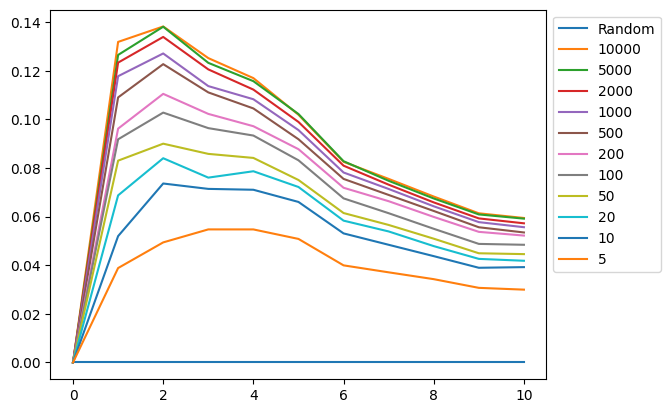

In [55]:
# plt.plot(np.mean(acc_curves_strategies['random'] , axis=0), label='Random')
# for key in acc_curves:
#     plt.plot(np.mean(acc_curves[key], axis=0), label=key)
plt.plot(np.mean(acc_curves_strategies['random'] - np.mean(acc_curves_strategies['random'], axis=0) , axis=0), label='Random')
for key in acc_curves:
    plt.plot(np.mean(acc_curves[key], axis=0) - np.mean(acc_curves_strategies['random'], axis=0), label=key)
    
plt.legend(bbox_to_anchor=(1, 1))

In [35]:
runs_dict = {}
client = mlflow.tracking.MlflowClient(tracking_uri=f'file:////home/dhuseljic/mlflow/perf_dal/optimal/')

experiment_id = client.get_experiment_by_name('retraining_v1').experiment_id
runs_dict['retrain_10'] = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(["parameter.dataset_name= 'cifar10'", "parameter.al.optimal.num_retraining_epochs = '10'" ]))
runs_dict['retrain_200'] = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(["parameter.dataset_name= 'cifar10'", "parameter.al.optimal.num_retraining_epochs = '200'" ]))
experiment_id = client.get_experiment_by_name('gamma_v1').experiment_id
runs_dict['update_1'] = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(["parameter.dataset_name= 'cifar10'", "parameter.al.optimal.gamma = '1'" ]))
runs_dict['update_7'] = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(["parameter.dataset_name= 'cifar10'", "parameter.al.optimal.gamma = '7'" ]))

acc_curves = defaultdict(list)
for key, runs in runs_dict.items():
    for run in runs:
        acc_curves[key].append([m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')])

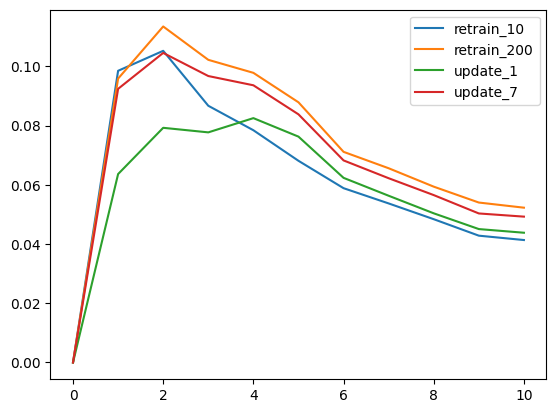

In [127]:
for key in acc_curves:
    plt.plot(np.mean(acc_curves[key], 0) - np.mean(acc_curves_strategies['random'], 0), label=key)
plt.legend()

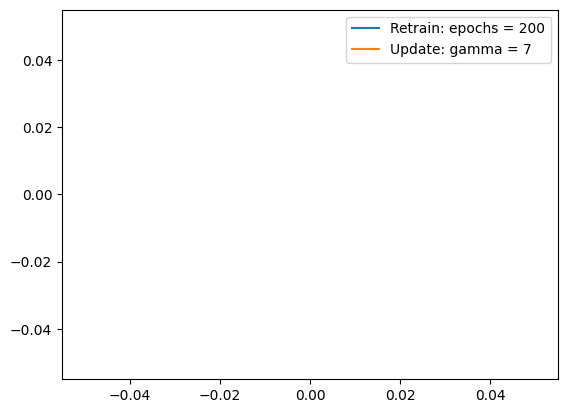